In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv('bankChurn.csv')

In [3]:
df.head(20)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [5]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


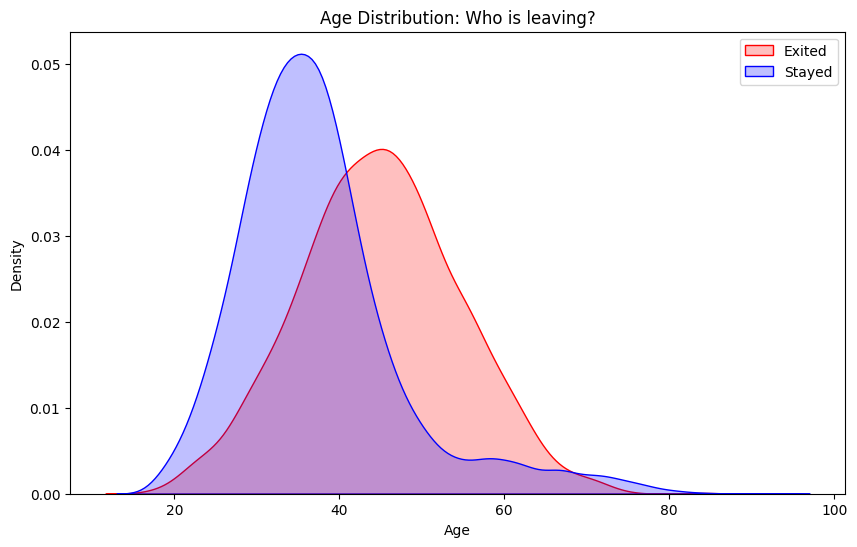

In [6]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Exited'] == 1]['Age'], label='Exited', fill=True, color='red')
sns.kdeplot(df[df['Exited'] == 0]['Age'], label='Stayed', fill=True, color='blue')
plt.title('Age Distribution: Who is leaving?')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [7]:
fig = px.pie(df,names="Geography",title="Country")
fig.show()

In [8]:
fig = px.pie(df,names="Gender",title="Gender Distribution", color_discrete_map={'Male':'cyan', 'Female':'black'})
fig.show()

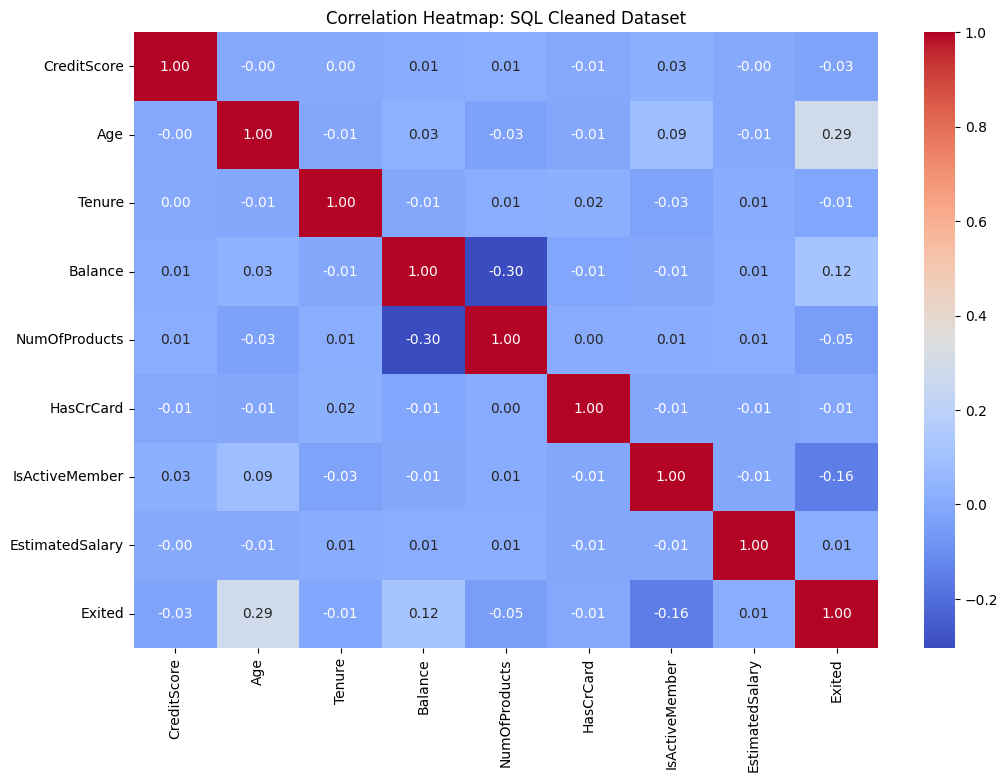

In [9]:
plt.figure(figsize=(12, 8))
# Only correlate numerical values
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: SQL Cleaned Dataset')
plt.show()

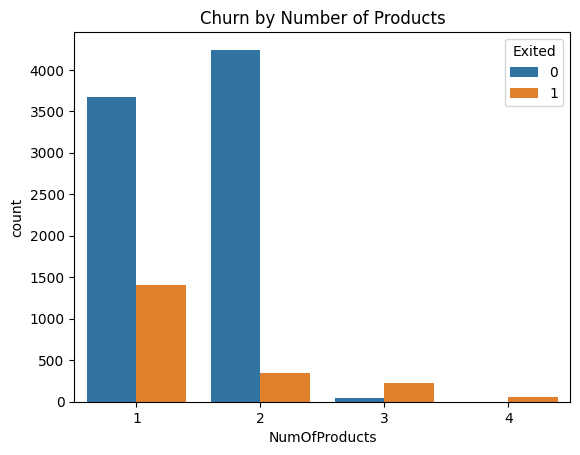

In [10]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title('Churn by Number of Products')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

In [12]:
# This turns text columns into 1s and 0s
df_ml = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [13]:
df_ml.head(20)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
5,645,44,8,113755.78,2,1,0,149756.71,1,False,True,True
6,822,50,7,0.00,2,1,1,10062.80,0,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,True,False,False
8,501,44,4,142051.07,2,0,1,74940.50,0,False,False,True
9,684,27,2,134603.88,1,1,1,71725.73,0,False,False,True


In [14]:
# this ddefine Features (X) and Target (y)
X = df_ml.drop('Exited', axis=1)
y = df_ml['Exited']

In [15]:
#test/train-80%/20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
#Feature Scaling (Pragmatic approach: Fit on Train only)
scaler = StandardScaler()
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [17]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

In [18]:
# We use the best model(Gradient Boosting) to predict for everyone
performance_report = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("--- Model Performance Comparison ---")
print(performance_report)

--- Model Performance Comparison ---
                 Model  Accuracy    Recall   ROC-AUC
2    Gradient Boosting    0.8700  0.488943  0.870831
1        Random Forest    0.8605  0.439803  0.850663
0  Logistic Regression    0.7135  0.700246  0.777181


In [19]:
best_model = models["Gradient Boosting"]

In [20]:
X_all_scaled = X.copy()
X_all_scaled[num_cols] = scaler.transform(X[num_cols])
full_probs = best_model.predict_proba(X_all_scaled)[:, 1]

In [22]:
df_final = pd.read_csv('Churn_Modelling.csv')
df_final['Churn_Probability'] = full_probs

In [23]:
df_final['Risk_Segment'] = df_final['Churn_Probability'].apply(
    lambda x: 'Critical' if x > 0.7 else ('Medium' if x > 0.4 else 'Low')
)

In [24]:
df_final.to_csv('Final_Churn_Predictions.csv', index=False)
print("\nSuccess! 'Final_Churn_Predictions.csv' is ready for Power BI.")


Success! 'Final_Churn_Predictions.csv' is ready for Power BI.
